# DATA 37100 — Final Project Analysis Template

Use this notebook to produce your analysis deliverable.

**Expected effort:** ~20 hours per student

## What to include
- Baseline summaries for **two** model families (GAN/DCGAN, Transformer, Diffusion)
- One **two‑knob** controlled experiment (exactly two factors)
- Side-by-side sample visualization (grids or text snippets)
- Evidence-based interpretation + at least one failure mode


## 1. Setup
Run from the **repo root**. Adjust paths if needed.

In [1]:
from pathlib import Path
import json
import pandas as pd

REPO_ROOT = Path.cwd().parent

# Diffusion outputs (default)
DIFF_OUT = REPO_ROOT / 'untrack/outputs/final/diffusion'

# Transformer outputs (default)
XFORM_OUT = REPO_ROOT / 'untrack/outputs/final/transformer'

DIFF_OUT, XFORM_OUT

(PosixPath('/Users/hongjiasu/Documents/GitHub/hongjiasu-final1/untrack/outputs/final/diffusion'),
 PosixPath('/Users/hongjiasu/Documents/GitHub/hongjiasu-final1/untrack/outputs/final/transformer'))

## 2. Select your experiment manifest (results.csv)

If you ran a grid experiment, you should have a `results.csv` with a `run_dir` column.

In [6]:
# Choose ONE
results_csv = DIFF_OUT / 'results.csv'   # or XFORM_OUT / 'results.csv'
print(results_csv)
df = pd.read_csv(results_csv)
df.head()

/Users/hongjiasu/Documents/GitHub/hongjiasu-final1/untrack/outputs/final/diffusion/results.csv


,run_dir,T,target
0,untrack/outputs/final/diffusion/ds-mnist_T-100...,100,eps
1,untrack/outputs/final/diffusion/ds-mnist_T-100...,100,x0
2,untrack/outputs/final/diffusion/ds-mnist_T-200...,200,eps
3,untrack/outputs/final/diffusion/ds-mnist_T-200...,200,x0
4,untrack/outputs/final/diffusion/ds-mnist_T-400...,400,eps


## 3. Quick run summary table
Each run directory should contain `run_args.json` and `summary.json`.

In [10]:
def read_json(p: Path):
    return json.loads(p.read_text(encoding='utf-8'))

rows = []
for rd in df['run_dir']:
    for rd in df['run_dir']:
        rd = Path(rd)
        if not rd.is_absolute():
            rd = REPO_ROOT / rd

    args = read_json(rd / 'run_args.json') if (rd / 'run_args.json').exists() else {}
    summ = read_json(rd / 'summary.json') if (rd / 'summary.json').exists() else {}
    row = {'run_dir': str(rd), 'name': rd.name}
    row.update({k: args.get(k) for k in ['dataset','T','target','beta2','base_ch','time_emb_dim','temperature','top_p','d_model','n_heads','n_layers'] if k in args})
    row.update({'seconds': summ.get('seconds'), 'device': summ.get('device')})
    rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df

,run_dir,name,dataset,T,target,beta2,base_ch,time_emb_dim,seconds,device
0,/Users/hongjiasu/Documents/GitHub/hongjiasu-fi...,ds-mnist_T-400_target-x0_b2-0.02_ch-64,mnist,400,x0,0.02,64,128,123.65,mps
1,/Users/hongjiasu/Documents/GitHub/hongjiasu-fi...,ds-mnist_T-400_target-x0_b2-0.02_ch-64,mnist,400,x0,0.02,64,128,123.65,mps
2,/Users/hongjiasu/Documents/GitHub/hongjiasu-fi...,ds-mnist_T-400_target-x0_b2-0.02_ch-64,mnist,400,x0,0.02,64,128,123.65,mps
3,/Users/hongjiasu/Documents/GitHub/hongjiasu-fi...,ds-mnist_T-400_target-x0_b2-0.02_ch-64,mnist,400,x0,0.02,64,128,123.65,mps
4,/Users/hongjiasu/Documents/GitHub/hongjiasu-fi...,ds-mnist_T-400_target-x0_b2-0.02_ch-64,mnist,400,x0,0.02,64,128,123.65,mps
5,/Users/hongjiasu/Documents/GitHub/hongjiasu-fi...,ds-mnist_T-400_target-x0_b2-0.02_ch-64,mnist,400,x0,0.02,64,128,123.65,mps


## 4. Visualize samples

For diffusion runs, the starter saves PNG grids in each run directory (or `samples/`).
We'll load the first grid we can find for each run and show a contact sheet.

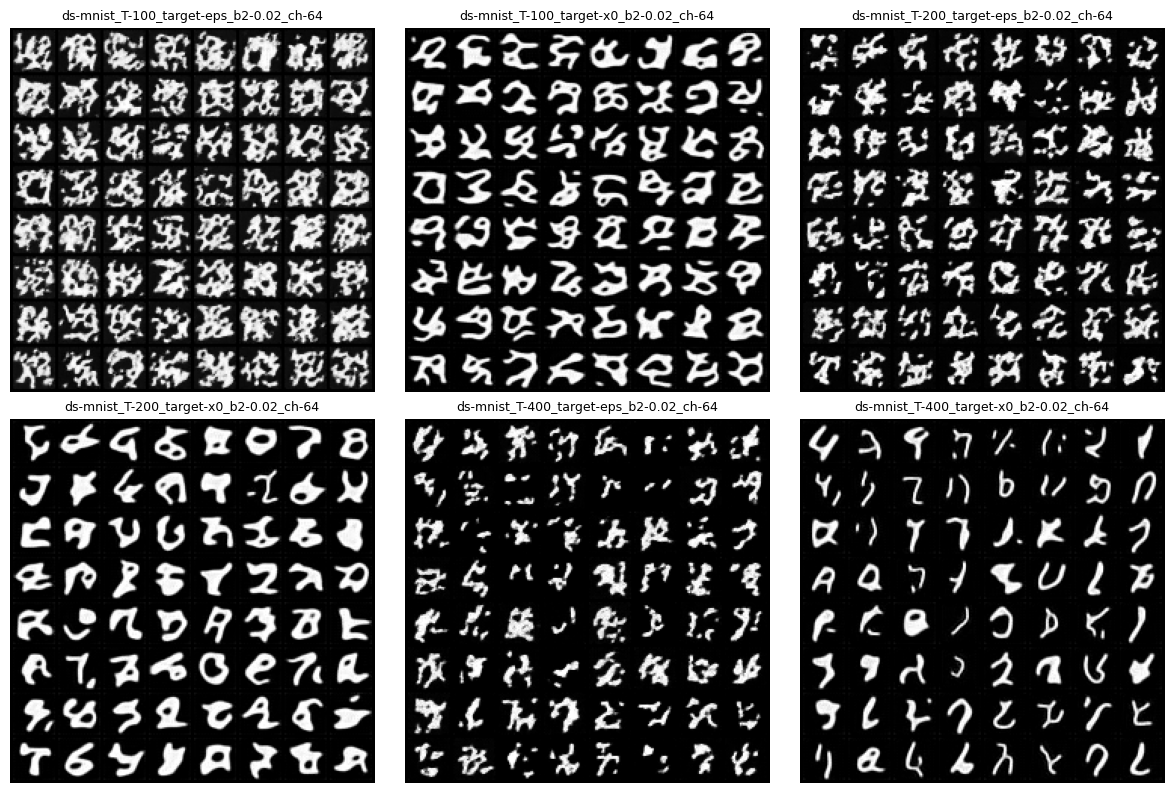

In [13]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import re

def find_pngs(run_dir: Path):
    candidates = []
    if (run_dir / 'samples').exists():
        candidates += list((run_dir / 'samples').glob('samples_step*.png'))
    candidates += list(run_dir.glob('samples_step*.png'))

    def extract_step(p):
        m = re.search(r"step(\d+)", p.name)
        return int(m.group(1)) if m else -1

    return sorted(candidates, key=extract_step, reverse=True)

imgs = []
titles = []
for rd in df['run_dir']:
    rd = Path(rd)
    if not rd.is_absolute():
        rd = REPO_ROOT / rd
    pngs = find_pngs(rd)
    if pngs:
        imgs.append(pngs[0])
        titles.append(rd.name)

n = len(imgs)
ncols = 3
nrows = (n + ncols - 1) // ncols
plt.figure(figsize=(4*ncols, 4*nrows))
for i, (p, t) in enumerate(zip(imgs, titles), start=1):
    ax = plt.subplot(nrows, ncols, i)
    ax.imshow(mpimg.imread(str(p)))
    ax.set_title(t, fontsize=9)
    ax.axis('off')
plt.tight_layout()

## 5. Simple diversity proxy (optional)

A lightweight metric for diffusion samples: average pairwise L2 distance in pixel space on a subset.

*This is intentionally simple and fast.*

In [18]:
import numpy as np

def diversity_proxy(x: np.ndarray, max_items: int = 64) -> float:
    # x: (N,H,W) or (N,H,W,C)
    x = x[:max_items].reshape(min(len(x), max_items), -1).astype(np.float32)
    n = x.shape[0]
    if n < 2:
        return float('nan')
    # sample a few pairs
    idx = np.random.default_rng(0).integers(0, n, size=(min(512, n*n), 2))
    d = np.linalg.norm(x[idx[:,0]] - x[idx[:,1]], axis=1)
    return float(d.mean())

print('Define how to load raw samples here if your run saves tensors; otherwise skip this section.')


Define how to load raw samples here if your run saves tensors; otherwise skip this section.


In [25]:
import json
import re
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.image as mpimg

def read_json(p: Path):
    return json.loads(p.read_text(encoding="utf-8"))

rows = []
for _, r in df.iterrows():
    rd = Path(r["run_dir"])
    if not rd.is_absolute():
        rd = REPO_ROOT / rd

    args = read_json(rd / "run_args.json") if (rd / "run_args.json").exists() else {}
    summ = read_json(rd / "summary.json") if (rd / "summary.json").exists() else {}

    rows.append({
        "run_dir": str(rd.resolve()),
        "name": rd.name,
        "T": args.get("T", r.get("T")),
        "target": args.get("target", r.get("target")),
        "seconds": summ.get("seconds"),
        "device": summ.get("device"),
    })

clean_df = pd.DataFrame(rows).sort_values(["T", "target"]).reset_index(drop=True)
clean_df

,run_dir,name,T,target,seconds,device
0,/Users/hongjiasu/Documents/GitHub/hongjiasu-fi...,ds-mnist_T-100_target-eps_b2-0.02_ch-64,100,eps,104.02,mps
1,/Users/hongjiasu/Documents/GitHub/hongjiasu-fi...,ds-mnist_T-100_target-x0_b2-0.02_ch-64,100,x0,101.28,mps
2,/Users/hongjiasu/Documents/GitHub/hongjiasu-fi...,ds-mnist_T-200_target-eps_b2-0.02_ch-64,200,eps,108.43,mps
3,/Users/hongjiasu/Documents/GitHub/hongjiasu-fi...,ds-mnist_T-200_target-x0_b2-0.02_ch-64,200,x0,121.52,mps
4,/Users/hongjiasu/Documents/GitHub/hongjiasu-fi...,ds-mnist_T-400_target-eps_b2-0.02_ch-64,400,eps,123.78,mps
5,/Users/hongjiasu/Documents/GitHub/hongjiasu-fi...,ds-mnist_T-400_target-x0_b2-0.02_ch-64,400,x0,123.65,mps


In [26]:
def find_final_sample_png(run_dir: Path):
    candidates = []
    if (run_dir / "samples").exists():
        candidates += list((run_dir / "samples").glob("samples_step*.png"))
    candidates += list(run_dir.glob("samples_step*.png"))

    if not candidates:
        return None

    def extract_step(p):
        m = re.search(r"step(\d+)", p.name)
        return int(m.group(1)) if m else -1

    candidates = sorted(candidates, key=extract_step, reverse=True)
    return candidates[0]

clean_df["sample_png"] = clean_df["run_dir"].apply(lambda x: str(find_final_sample_png(Path(x))) if find_final_sample_png(Path(x)) else None)
clean_df[["name", "T", "target", "sample_png"]]

,name,T,target,sample_png
0,ds-mnist_T-100_target-eps_b2-0.02_ch-64,100,eps,/Users/hongjiasu/Documents/GitHub/hongjiasu-fi...
1,ds-mnist_T-100_target-x0_b2-0.02_ch-64,100,x0,/Users/hongjiasu/Documents/GitHub/hongjiasu-fi...
2,ds-mnist_T-200_target-eps_b2-0.02_ch-64,200,eps,/Users/hongjiasu/Documents/GitHub/hongjiasu-fi...
3,ds-mnist_T-200_target-x0_b2-0.02_ch-64,200,x0,/Users/hongjiasu/Documents/GitHub/hongjiasu-fi...
4,ds-mnist_T-400_target-eps_b2-0.02_ch-64,400,eps,/Users/hongjiasu/Documents/GitHub/hongjiasu-fi...
5,ds-mnist_T-400_target-x0_b2-0.02_ch-64,400,x0,/Users/hongjiasu/Documents/GitHub/hongjiasu-fi...


In [27]:
def load_grid_samples(png_path, grid_size=8):
    img = mpimg.imread(str(png_path))

    if img.ndim == 3:
        img = img[..., 0]

    H, W = img.shape
    h = H // grid_size
    w = W // grid_size

    samples = []
    for i in range(grid_size):
        for j in range(grid_size):
            samples.append(img[i*h:(i+1)*h, j*w:(j+1)*w])

    return np.stack(samples)

In [28]:
div_rows = []

for _, r in clean_df.iterrows():
    png_path = r["sample_png"]
    if png_path is None:
        continue

    samples = load_grid_samples(Path(png_path))
    div = diversity_proxy(samples)

    div_rows.append({
        "name": r["name"],
        "T": r["T"],
        "target": r["target"],
        "diversity": div,
    })

div_df = pd.DataFrame(div_rows).sort_values(["T", "target"]).reset_index(drop=True)
div_df

,name,T,target,diversity
0,ds-mnist_T-100_target-eps_b2-0.02_ch-64,100,eps,11.843430
1,ds-mnist_T-100_target-x0_b2-0.02_ch-64,100,x0,13.146294
2,ds-mnist_T-200_target-eps_b2-0.02_ch-64,200,eps,12.012733
3,ds-mnist_T-200_target-x0_b2-0.02_ch-64,200,x0,11.911119
4,ds-mnist_T-400_target-eps_b2-0.02_ch-64,400,eps,11.042006
5,ds-mnist_T-400_target-x0_b2-0.02_ch-64,400,x0,9.771448


## 6. Failure modes & limitations (required)

Write short, evidence-based notes: 
- What artifacts appeared? When? 
- Which knob changes increased/decreased failures? 
- What does this imply about model assumptions?


Artifacts observed:

For T = 100 with ε prediction, the generated images contain noticeable noise and fragmented strokes. Many digits are partially formed and contain scattered white pixels, indicating incomplete denoising. For x₀ prediction, the dominant artifact is oversmoothing. The generated shapes tend to collapse into thick, blob-like structures that resemble averaged digit shapes rather than clear handwritten digits. 

Effect of knob changes:

Increasing the diffusion steps T generally reduces noise artifacts and improves digit structure. For example, the ε model improves visibly from T=100 to T=400, where digits become more coherent and recognizable. Changing the prediction target also affects the failure mode. ε prediction tends to produce sharper but sometimes noisy digits, while x₀ prediction produces smoother images but introduces structural collapse, where many digits look similar or blob-like.

Implications about model assumptions:

These results suggest that the diffusion process benefits from sufficient denoising steps to gradually refine image structure. With too few steps, the model cannot fully remove noise. The difference between ε and x₀ targets also reflects different optimization behavior. Predicting ε appears to preserve fine structure better, while predicting x₀ tends to regress toward average pixel patterns, leading to smoother but less detailed samples

## 7. Conclusions (required)

In 5–8 bullet points:
- Key findings
- One surprising result
- One limitation
- One next step


- Increasing the diffusion step count T improves sample quality by reducing noise and producing clearer digit structures.

- $\epsilon$ prediction generally generates sharper and more recognizable digits than $x_0$ prediction.

- $x_0$ prediction tends to produce smoother but overly averaged shapes, leading to blob-like digits.

- A surprising result is that the highest diversity score occurs at T=100 with $x_0$, even though the visual quality is relatively poor.

- One limitation is that the experiment uses only one training epoch, which likely limits the final sample quality.

- A natural next step would be to train the model longer or test additional knobs such as noise schedules or model width.